In [5]:
import os
os.chdir('/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src')

# Libraries

In [6]:
from operator import itemgetter
from tqdm import tqdm
import time
from datetime import datetime
import json
import copy

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import importlib

import seaborn as sns

import geopandas as gpd
import xarray
import rioxarray
import fiona

import shapely
from shapely.geometry import box

# Colormap
import cmasher as cmr

import geopy.distance

In [7]:
from dataloaders import dataset_ST_MultiPoint
# from dataloaders import load_dataset
# from loss import losses_SparseData
# from models import models_SparseData
# from optimizer import load_optimizer

from subprocess import Popen

# Data

In [8]:
main_dir = "/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl"


In [9]:
json_file = "/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/config/train_test_PSTAINet_ILB.json" #config_files_1d/lstm_att_1.json
dict_files = {}
with open(json_file) as f:
    dict_files = json.load(f)
    print(f"Read data.json: {dict_files}")

Read data.json: {'cuda_device': 'cuda:0', 'seed': 42, 'entity': 'gsartor-unito', 'experiment_name': 'ST_MultiPoint', 'run_name': 'PI_S_ref', 'comments': None, 'wandb_mode': 'offline', 'wandb_dir': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/results/results_ST_MultiPoint/logs', 'save_model_dir': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/results/results_ST_MultiPoint/runs', 'dtm_nc': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/dtm_ROI.nc', 'weather_nc_path': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/era5land_2000_2024_weekly.nc', 'weather_dtm': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/era5land_dtm.nc', 'wtd_csv_path': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/dataset_wtd_roi.csv', 'wtd_shp': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/shapefile/underground_wtd_sensor_roi.shp', 'piedmont_shp': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/shapefile/piemonte_admin_boundaries.shp', 'recharge_areas_shp': '/leonardo_

In [10]:
ds = dataset_ST_MultiPoint.Dataset_ST_MultiPoint(dict_files)

    Loading weather data... 

/leonardo_scratch/fast/IscrC_DL4STP/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Done!
    Loading dtm... Done!
    Loading Piedmont Shapefiles... 

/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src/dataloaders/dataset_ST_MultiPoint.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  clipped_buffer = clipped.buffer(buffer_recharge)


Done!
    Loading underground water data... Done!
    Norm factors:
{'target_means': np.float64(297.1249160768408), 'target_stds': np.float64(73.38987997145817), 'dtm_mean': <xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 4B
array(1139.4907, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0, 'dtm_std': <xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 4B
array(884.7991, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0, 'lat_mean': np.float64(44.800499999999964), 'lat_std': np.float64(0.3169655454549103), 'lon_mean': np.float64(7.375499999999998), 'lon_std': np.float64(0.4326943495034695), 'weather_mean': <xarray.Dataset> Size: 24B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0
Data variables:
    tp           float32 4B 0.001774
    t2m          float32 4B 280.5
    pev          float32 4B -0.001865
    smlt         float32 4B 0.000512, 'weather_std': <xarray.Dataset> Size: 24B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0

In [11]:
# Italy shp
italy_shp = gpd.read_file(f"{main_dir}/data/shapefile/Italy_Reg01012024_g_WGS84.shp", engine='fiona')
italy_shp = italy_shp.to_crs('epsg:4326')

In [12]:
# Piedmont DTM (precise border)
piemonte_dtm = rioxarray.open_rasterio(f"{main_dir}/data/DTMPiemonte_filled_50m.tif", engine='fiona')
piemonte_dtm = piemonte_dtm.rio.reproject("epsg:4326")
piemonte_dtm = piemonte_dtm.where(piemonte_dtm != -99999) # Take valid pixel

In [13]:
# extract Province names and coord, useful for plots
provinces_names = [ds.piemonte_shp["nome"][i] for i in range(0,len(ds.piemonte_shp))]
provinces_long = [ds.piemonte_shp["geometry"][i].representative_point().coords[0][0] for i in range(0,len(ds.piemonte_shp))]
provinces_lat = [ds.piemonte_shp["geometry"][i].representative_point().coords[0][1] for i in range(0,len(ds.piemonte_shp))]
provinces_lat[-3] = provinces_lat[-3] - 0.25
provinces_long[-3] = provinces_long[-3] - 0.05

In [14]:
# Load river shp
rivers_shp_100 = gpd.read_file(f"{main_dir}/data/shapefile/idro100-fiumi.shp", engine='fiona')
rivers_shp_100 = rivers_shp_100.to_crs('epsg:4326')

In [15]:
roi_box = [ds.dtm_roi.x.min().values,
        ds.dtm_roi.x.max().values,
        ds.dtm_roi.y.min().values,
        ds.dtm_roi.y.max().values]
roi_box

[array(6.62666667), array(8.02916667), array(44.31083333), array(45.265)]

# Distances

In [12]:
# Compute the resolution in km
spatial_resolution_meteo =  geopy.distance.geodesic((ds.weather_xr["lat"].values[0],
                               ds.weather_xr["lon"].values[0]),
                               (ds.weather_xr["lat"].values[1],
                                ds.weather_xr["lon"].values[0])).km
print("Weather Lat Resolution in km: ", round(spatial_resolution_meteo, 3))

Weather Lat Resolution in km:  11.114


In [13]:
# Compute the resolution in km
spatial_resolution_meteo =  geopy.distance.geodesic((ds.weather_xr["lat"].values[0],
                               ds.weather_xr["lon"].values[0]),
                               (ds.weather_xr["lat"].values[0],
                                ds.weather_xr["lon"].values[1])).km
print("Weather Lon Resolution in km: ", round(spatial_resolution_meteo, 3))

Weather Lon Resolution in km:  7.842


# Sensor Map

In [16]:
roi_box = box(ds.dtm_roi.x.min().values, ds.dtm_roi.y.min().values, ds.dtm_roi.x.max().values, ds.dtm_roi.y.max().values)

In [17]:
# Compute sensor norm factors
denorm_target = copy.deepcopy(ds.wtd_df[ds.target])
denorm_target = (denorm_target * ds.norm_factors["target_stds"])+ds.norm_factors["target_means"]


target_means = denorm_target.groupby(level=1).transform('mean').values
target_means = target_means.reshape(len(ds.wtd_df.index)//len(ds.sensor_id_list),
                                    len(ds.sensor_id_list))[0,:] 


target_stds = denorm_target.groupby(level=1).transform('std').values
target_stds = target_stds.reshape(len(ds.wtd_df.index)//len(ds.sensor_id_list),
                                    len(ds.sensor_id_list))[0,:]

In [16]:
# # All pidemont dtm maps 

# fig, ax = plt.subplots(figsize = (7,7))

# # Log-Scale: Define the ticks
# cnorm = matplotlib.colors.LogNorm(vmin=piemonte_dtm.min(), vmax=piemonte_dtm.max())
# decades = np.ceil(np.log10(cnorm.vmax / cnorm.vmin))
# formatter = matplotlib.ticker.LogFormatter(10, minor_thresholds=(decades, decades))

# # Plot with lognorm transformation
# piemonte_elevation = piemonte_dtm.plot(ax = ax, add_colorbar=False,
#                                     cmap = cmr.get_sub_cmap(plt.cm.terrain, 0.25,1),
#                                     norm = matplotlib.colors.LogNorm(vmin = piemonte_dtm.min().values,
#                                                                     vmax = piemonte_dtm.max().values))
# ax.set_title("Piedmont (IT)")
# ax.set_xlabel("Longitude [°E]")
# ax.set_ylabel("Latitude [°N]")

# # Regional shapefile
# ds.piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.7, alpha = 0.6, ax = ax, label = "Administrative bounds")

# # Rivers
# rivers_shp_100.loc[rivers_shp_100["CLASSE"] == 1].plot(ax = ax, linewidth=0.3, label = "Rivers")

# # Provinces labels
# texts = []
# for x, y, label in zip(provinces_long, provinces_lat, provinces_names):

#     texts.append(plt.text(x,y,label, ha='center', va='center' ,
#                         fontsize =9, fontweight = "bold", fontstyle = "italic", color = "Black"))

#     aT.adjust_text(texts, force_text =(0.1, 0.1), force_explode=(0, 0), #, min_arrow_len = 5
#                     force_static =(0, 0),
#                     arrowprops=dict(arrowstyle="simple", linestyle = "--", color='dimgrey', lw=1.2))
    
# # ROI box
# ax.plot(*roi_box.exterior.xy, label = "ROI", color = "magenta")

# # Italy Inset
# #inset_object = [italy_borders, Piemonte_box.exterior.xy]
# piemonte_long_min, piemonte_lat_min, piemonte_long_max, piemonte_lat_max = ds.piemonte_shp.total_bounds
# piemonte_box = box(piemonte_long_min, piemonte_lat_min, piemonte_long_max , piemonte_lat_max)

# box(piemonte_long_min, piemonte_lat_min, piemonte_long_max , piemonte_lat_max)
# axins = ax.inset_axes(bounds = [0,0.65,0.35,0.35])
# italy_shp.boundary.plot(ax = axins, color = 'gray', linewidth = 0.5) # Italy
# axins.plot(*piemonte_box.exterior.xy, color = "black") # Piemonte
# axins.set_xticks([])
# axins.set_yticks([])

# # Sensors

# gw_points = ax.scatter(
#     ds.wtd_geodf.geometry.x, ds.wtd_geodf.geometry.y,
#     marker="o",
#     c="darkred",  #ds.wtd_geodf['means'],
#     cmap=cmr.get_sub_cmap(plt.cm.Blues, 0.3,1),
#     edgecolor='black',
#     linewidths = 0.5,
#     zorder = 1000,
#     s=20)

# plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25))

# # Colorbar for DTM
# ticks = [cnorm.vmin, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000]
# ticks.append(cnorm.vmax)
# fig.colorbar(ticks=ticks, mappable=piemonte_elevation,
#                 format = formatter, label = "Elevation [m]")

# ## North arrow
# north_x_shift = 1.05
# north_y_shift = -0.18
# north_fontsize = 15
# arrow_dx = 0
# arrow_dy = 0.1
# arrow_x_shift = 1.105
# arrow_y_shift = -0.3
# arrow_head_width=0.08
# arrow_head_length=0.1
# ax.text(x=ax.get_xlim()[0]+north_x_shift-0.05, y=ax.get_ylim()[1]+north_y_shift, s='N', fontsize=north_fontsize)
# ax.arrow(ax.get_xlim()[0]+arrow_x_shift, ax.get_ylim()[1]+arrow_y_shift, arrow_dx, arrow_dy, length_includes_head=True,
#         head_width=arrow_head_width, head_length=arrow_head_length, overhang=.1, facecolor='k')

# #plt.savefig(f"{save_plot_dir}/piemonte.png", dpi = 600, transparent = True, bbox_inches = 'tight')

# plt.plot()

## Crop

In [18]:
piemonte_dtm_clipped = piemonte_dtm.rio.clip_box(ds.dtm_roi.x.min().values,
        ds.dtm_roi.y.min().values,
        ds.dtm_roi.x.max().values,
        ds.dtm_roi.y.max().values)

# Approximate coordinates (lon, lat) for the cities
city_coords = {
    "Torino": (7.6867, 45.0706, (0,0.02)),
    "Cuneo": (7.5427, 44.3845, (0,-0.05)),
    "Carmagnola": (7.7203, 44.8496, (0.15,-0.04)),
    "Bra": (7.8500, 44.7000, (0.05,0)),
    "Savigliano": (7.6330, 44.6500, (0.125,-0.045)),
    "Susa": (7.0484, 45.1385, (0,0.02)),
    "Pinerolo": (7.3333, 44.8833, (0,0.02)),
    "Racconigi": (7.6740, 44.7687, (0,-0.045)),
    "Saluzzo": (7.4920, 44.6478, (0,-0.05)),
    "Fossano": (7.7194, 44.5503, (0.02,-0.045))
}

/scratch_local/ipykernel_72241/1517090591.py:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  gw_points = ax.scatter(


[]

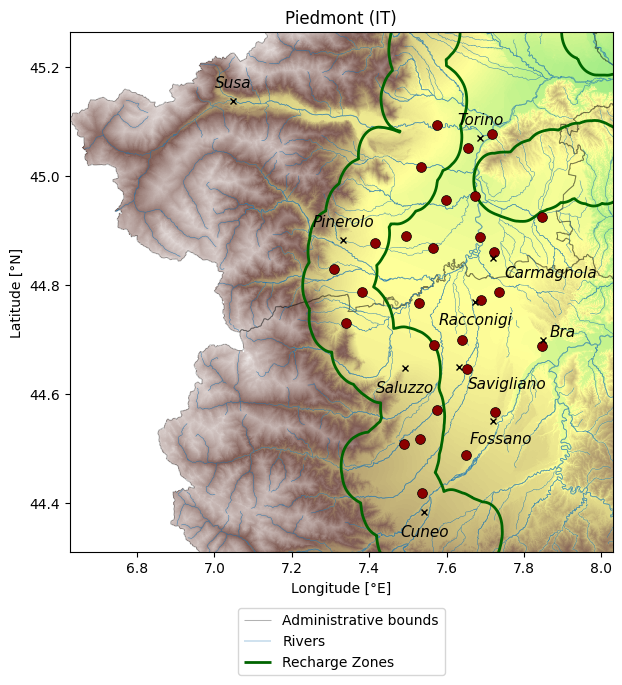

In [25]:
fig, ax = plt.subplots(figsize = (7,7))

# Plot with lognorm transformation
piemonte_elevation = piemonte_dtm_clipped.plot(ax = ax, add_colorbar=False,
                                      cmap = cmr.get_sub_cmap(plt.cm.terrain, 0.25,1),
                                      norm = matplotlib.colors.LogNorm(vmin = piemonte_dtm.min().values,
                                                                       vmax = piemonte_dtm.max().values))
ax.set_title("Piedmont (IT)")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")

# Regional shapefile
ds.piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.75, alpha = 0.3, ax = ax, label = "Administrative bounds")

# Rivers
rivers_shp_100.loc[rivers_shp_100["CLASSE"] == 1].plot(ax = ax, linewidth=0.3, label = "Rivers")

# City Labels
for city, (lon, lat,(dx,dy)) in city_coords.items():
    ax.plot(lon, lat, marker="x", color='black', markersize=4, zorder=2000)  # add point
    ax.text(lon + dx, lat + dy, city, fontsize=11,
        ha='center',
        va='bottom',
        fontstyle = "italic",
        color='black', zorder=2000)

# Recharge zones
ds.recharge_area_buffer_shp.boundary.plot(color = 'darkgreen', linewidth = 2, ax = ax, label = "Recharge Zones")

# Sensors
gw_points = ax.scatter(
    ds.wtd_geodf.geometry.x, ds.wtd_geodf.geometry.y,
    marker="o",
    c="darkred",#ds.wtd_geodf['means'],
    cmap=cmr.get_sub_cmap(plt.cm.Blues, 0.3,1),
    edgecolor="black",#'darkred',
    linewidths = 0.5,
    zorder = 1000,
    s=50)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25))

# Colorbar for points
#ticks_h = np.linspace(ds.wtd_geodf['means'].min(), ds.wtd_geodf['means'].max(),10)
#plt.colorbar(mappable = gw_points, ticks= ticks_h, label = "Mean Groundwater Level [m]")

# plt.savefig(f"{save_plot_dir}/rch_zones.png", dpi = 600, transparent = True, bbox_inches = 'tight')

plt.plot()

In [ ]:
#2008-07-06
#2009-05-03

date = "2009-05-03"
discard_sensor = None #["Busca","Cuneo"]
vmin = 1
vmax = 50

city_coords = {
    "Torino": (7.6867, 45.0706, (0,-0.04)),
    "Cuneo": (7.5427, 44.3845, (0,-0.05)),
    #"Carmagnola": (7.7203, 44.8496, (0.185,-0.02)),
    "Bra": (7.8500, 44.7000, (0.08,-0.02)),
    "Savigliano": (7.6330, 44.6500, (-0.155,-0.015)),
    #"Susa": (7.0484, 45.1385, (0,0.02)),
    "Fossano": (7.7194, 44.5503, (0.125,-0.02))
}

fig, ax = plt.subplots(figsize = (7,7))

# Plot with lognorm transformation
piemonte_elevation = piemonte_dtm_clipped.plot(ax = ax, add_colorbar=False,
                                      cmap = cmr.get_sub_cmap(plt.cm.terrain, 0.25,1),
                                      norm = matplotlib.colors.LogNorm(vmin = piemonte_dtm.min().values,
                                                                       vmax = piemonte_dtm.max().values))
ax.set_title("Piedmont (IT)")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")

# Regional shapefile
ds.piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.75, alpha = 0.3, ax = ax, label = "Administrative bounds")

# Rivers
rivers_shp_100.loc[rivers_shp_100["CLASSE"] == 1].plot(ax = ax, linewidth=0.3, label = "Rivers")

# City Labels
for city, (lon, lat,(dx,dy)) in city_coords.items():
    ax.plot(lon, lat, marker="x", color='black', markersize=6, zorder=2000)  # add point
    ax.text(lon + dx, lat + dy, city, fontsize=11,
        ha='center',
        va='bottom',
        weight='bold',
        fontstyle = "italic",
        color='black', zorder=2000)

# Recharge zones
#ds.recharge_area_buffer_shp.boundary.plot(color = 'darkgreen', linewidth = 2, ax = ax, label = "Recharge Zones")

#colors = ds.wtd_df.loc[ds.wtd_df.index.get_level_values(0) == np.datetime64("2008-07-06"),"wtd"].reset_index(drop = True)

wtd_min_ds = copy.deepcopy(wtd_min_2008_2009)

if discard_sensor:
    subset_idx = [] 
    for s in discard_sensor:
        subset_idx.append(ds.wtd_geodf.loc[ds.wtd_geodf["munic"] == s,:].index.values[0])
    
    wtd_min_ds = wtd_min_ds.drop(labels = subset_idx)
    suffix = "_less"
else:
    suffix = ""

subset_geodf = ds.wtd_geodf.loc[wtd_min_ds.index,:]
   
if date=="2009-05-03":
    date_wtd = "wtd_052009"
    
elif date=="2008-07-06":
    date_wtd = "wtd_072008"
    
# Sensors
gw_points = ax.scatter(
    subset_geodf.geometry.x, subset_geodf.geometry.y,
    marker="o",
    c=wtd_min_ds[date_wtd],
    cmap="RdYlGn", #cmr.get_sub_cmap(plt.cm.Blues, 0.3,1),
    edgecolor='darkred',
    linewidths = 0.5,
    zorder = 1000,
    s=100)

# Write number 
for i,(x,y) in enumerate(zip(subset_geodf.geometry.x, subset_geodf.geometry.y)):

    ax.text(x, y + 0.015, round(wtd_min_ds[date_wtd].values[i]), fontsize=11,
        ha='center',
        va='bottom',
        weight='bold',
        fontstyle = "italic",
        color='black', zorder=2000)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2))

# Colorbar for points
#ticks_h = np.round(np.linspace(np.floor(wtd_min_2008_2009[date_wtd].min()), np.ceil(wtd_min_2008_2009[date_wtd].max()),10))

ticks_h = np.round(np.linspace(vmin,vmax,10))
plt.colorbar(mappable = gw_points, ticks= ticks_h, label = "Water Table Depth [m]", extend = "both")
plt.title(date)

plt.ylim(ds.dtm_roi.y.min(),ds.dtm_roi.y.max())
plt.xlim(7.2,ds.dtm_roi.x.max())

plt.savefig(f"{save_plot_dir}/wtd_piemonte_{date.replace('-','_')}_alt{suffix}.png", dpi = 600, transparent = True, bbox_inches = 'tight')

plt.plot()

# Soil properties

In [130]:
esai_tex = rioxarray.open_rasterio(f"{main_dir}/data/soil_properties/ESAI_tex.tif").rio.write_crs("32632", inplace=True)
esai_tex = esai_tex.rio.reproject("epsg:4326")
esai_tex = esai_tex.where((esai_tex[0]<9) & (esai_tex[0]>-100), np.nan)

esai_sk = rioxarray.open_rasterio(f"{main_dir}/data/soil_properties/Esai_sk.tif").rio.write_crs("32632", inplace=True)
esai_sk = esai_sk.rio.reproject("epsg:4326")
esai_sk = esai_sk.where((esai_sk[0]<9) & (esai_sk[0]>-100), np.nan)

esai_dren = rioxarray.open_rasterio(f"{main_dir}/data/soil_properties/Esai_dren.tif").rio.write_crs("32632", inplace=True)
esai_dren = esai_dren.rio.reproject("epsg:4326")
esai_dren = esai_dren.where((esai_dren[0]<9) & (esai_dren[0]>-100), np.nan)

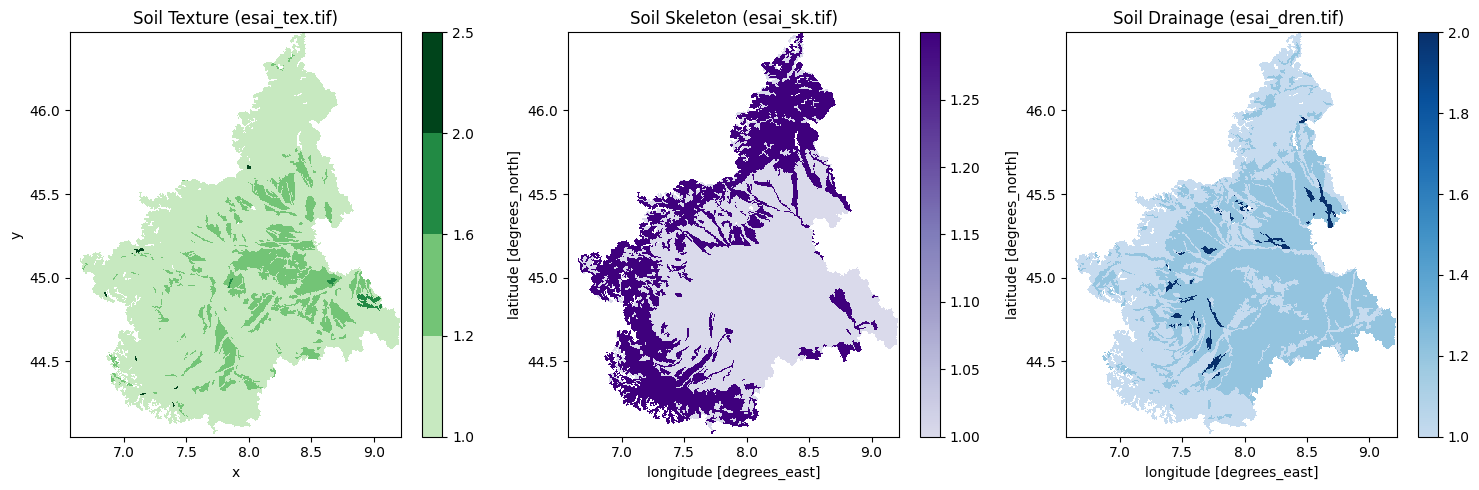

In [138]:
fig, ax = plt.subplots(1,3, figsize = (15,5))

esai_tex.plot(ax=ax[0], cmap = cmr.get_sub_cmap("Greens", 0.25,1), levels=[1, 1.2, 1.6, 2, 2.5])
ax[0].set_title("Soil Texture (esai_tex.tif)")

esai_sk.plot(ax=ax[1], cmap = cmr.get_sub_cmap("Purples", 0.25,1))
ax[1].set_title("Soil Skeleton (esai_sk.tif)")

esai_dren.plot(ax=ax[2], cmap = cmr.get_sub_cmap("Blues", 0.25,1))
ax[2].set_title("Soil Drainage (esai_dren.tif) ")
# 1: rapido, moderatamente rapido
# 1.2: buono, mediocre
# 2: lento, molto lento, impedito
plt.tight_layout()

In [192]:
esai_tex = xarray.where(esai_tex == 2, np.nan, esai_tex)

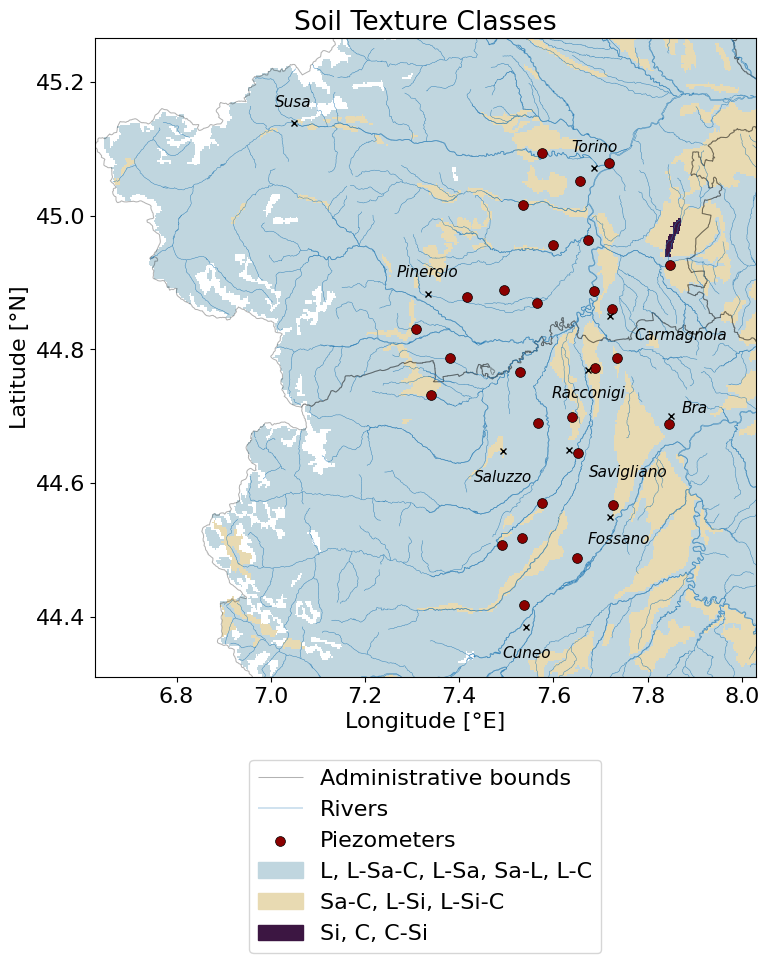

In [253]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import adjustText as aT

plt.rcParams.update({'font.size': 16,
                        'ytick.labelsize': 16,
                        'xtick.labelsize': 16})

#Loam, sandy, silty, clayey
unique_labels = ["L, L-Sa-C, L-Sa, Sa-L, L-C",
                 "Sa-C, L-Si, L-Si-C",
                 "Si, C, C-Si"]
# ['#cad2c5', '#84a98c', '#52796f', '#22333b']
cmap = mcolors.ListedColormap(['#c0d6df', '#e8dab2', '#3c1642'])  # pick colors for each class
bounds = [1, 1.2, 1.6, 2]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9,9.5))
im = esai_tex.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

# Regional shapefile
ds.piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.75, alpha = 0.3, ax = ax, label = "Administrative bounds")

# Rivers
rivers_shp_100.loc[rivers_shp_100["CLASSE"] == 1].plot(ax = ax, linewidth=0.3, label = "Rivers")

# Sensors
gw_points = ax.scatter(
    ds.wtd_geodf.geometry.x, ds.wtd_geodf.geometry.y,
    marker="o",
    c="darkred",#ds.wtd_geodf['means'],
    edgecolor="black",#'darkred',
    linewidths = 0.5,
    zorder = 1000,
    label = "Piezometers",
    s=50)

# City Labels
for city, (lon, lat,(dx,dy)) in city_coords.items():
    ax.plot(lon, lat, marker="x", color='black', markersize=4, zorder=2000)  # add point
    ax.text(lon + dx, lat + dy, city, fontsize=11,
        ha='center',
        va='bottom',
        fontstyle = "italic",
        color='black', zorder=2000)
    
ax.set_xlim((ds.dtm_roi.x.min().values,
             ds.dtm_roi.x.max().values))

ax.set_ylim((ds.dtm_roi.y.min().values,
             ds.dtm_roi.y.max().values))


# Get existing legend entries
handles, labels = ax.get_legend_handles_labels()

for i, label in enumerate(unique_labels):
    
    handles.append(Patch(color=cmap(i)))
    labels.append(label)

ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.45))

ax.set_title("Soil Texture Classes")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
plt.tight_layout()
plt.savefig("/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/soil_texture/soil_texture_roi.jpeg", dpi = 600, transparent = True, bbox_inches = 'tight' )

plt.show()

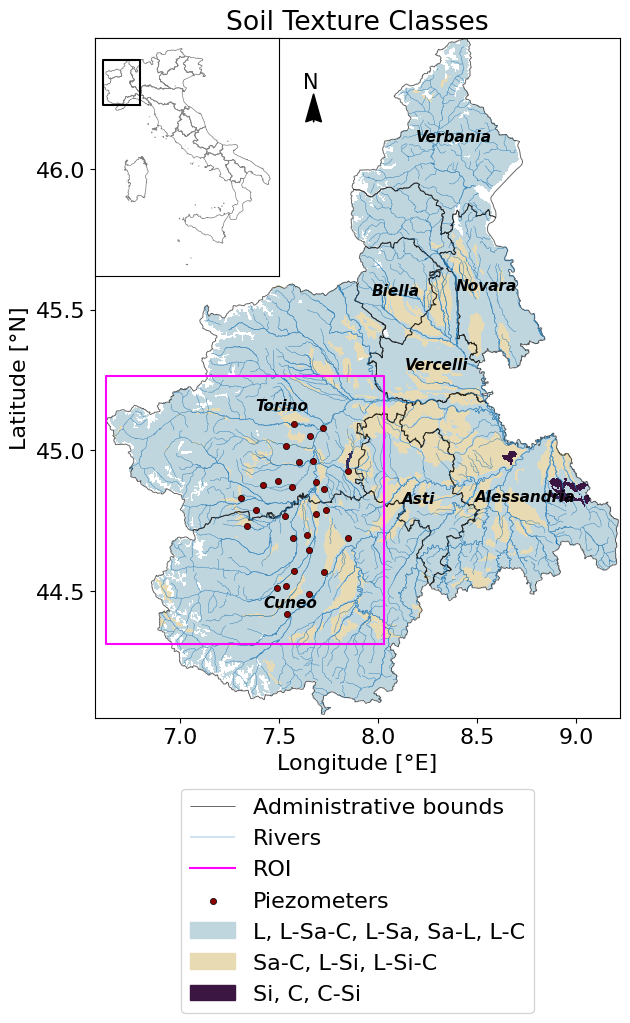

In [242]:
plt.rcParams.update({'font.size': 16,
                        'ytick.labelsize': 16,
                        'xtick.labelsize': 16})

#Loam, sandy, silty, clayey
unique_labels = ["L, L-Sa-C, L-Sa, Sa-L, L-C",
                 "Sa-C, L-Si, L-Si-C",
                 "Si, C, C-Si"]
# ['#cad2c5', '#84a98c', '#52796f', '#22333b']
cmap = mcolors.ListedColormap(['#c0d6df', '#e8dab2', '#3c1642'])  # pick colors for each class
bounds = [1, 1.2, 1.6, 2]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(7,10))
im = esai_tex.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

# Regional shapefile
ds.piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.7, alpha = 0.6, ax = ax, label = "Administrative bounds")

# Rivers
rivers_shp_100.loc[rivers_shp_100["CLASSE"] == 1].plot(ax = ax, linewidth=0.3, label = "Rivers")

# Provinces labels
texts = []
for x, y, label in zip(provinces_long, provinces_lat, provinces_names):

    texts.append(plt.text(x,y,label, ha='center', va='center' ,
                        fontsize =11, fontweight = "bold", fontstyle = "italic", color = "Black"))

    aT.adjust_text(texts, force_text =(0.1, 0.1), force_explode=(0, 0), #, min_arrow_len = 5
                    force_static =(0, 0),
                    arrowprops=dict(arrowstyle="simple", linestyle = "--", color='dimgrey', lw=1.2))
    
# ROI box
ax.plot(*roi_box.exterior.xy, label = "ROI", color = "magenta")

# Italy Inset
#inset_object = [italy_borders, Piemonte_box.exterior.xy]
piemonte_long_min, piemonte_lat_min, piemonte_long_max, piemonte_lat_max = ds.piemonte_shp.total_bounds
piemonte_box = box(piemonte_long_min, piemonte_lat_min, piemonte_long_max , piemonte_lat_max)

box(piemonte_long_min, piemonte_lat_min, piemonte_long_max , piemonte_lat_max)
axins = ax.inset_axes(bounds = [0,0.65,0.35,0.35])
italy_shp.boundary.plot(ax = axins, color = 'gray', linewidth = 0.5) # Italy
axins.plot(*piemonte_box.exterior.xy, color = "black") # Piemonte
axins.set_xticks([])
axins.set_yticks([])

# Sensors

gw_points = ax.scatter(
    ds.wtd_geodf.geometry.x, ds.wtd_geodf.geometry.y,
    marker="o",
    c="darkred",  #ds.wtd_geodf['means'],
    edgecolor='black',
    linewidths = 0.5,
    zorder = 1000,
    label = "Piezometers",
    s=20)

# plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35))

# Get existing legend entries
handles, labels = ax.get_legend_handles_labels()

for i, label in enumerate(unique_labels):
    
    handles.append(Patch(color=cmap(i)))
    labels.append(label)

ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.45))

## North arrow
north_x_shift = 1.1
north_y_shift = -0.18
north_fontsize = 15
arrow_dx = 0
arrow_dy = 0.1
arrow_x_shift = 1.105
arrow_y_shift = -0.3
arrow_head_width=0.08
arrow_head_length=0.1
ax.text(x=ax.get_xlim()[0]+north_x_shift-0.05, y=ax.get_ylim()[1]+north_y_shift, s='N', fontsize=north_fontsize)
ax.arrow(ax.get_xlim()[0]+arrow_x_shift, ax.get_ylim()[1]+arrow_y_shift, arrow_dx, arrow_dy, length_includes_head=True,
        head_width=arrow_head_width, head_length=arrow_head_length, overhang=.1, facecolor='k')

ax.set_title("Soil Texture Classes")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
plt.tight_layout()

plt.savefig("/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/soil_texture/soil_texture_piedmont.jpeg", dpi = 600, transparent = True, bbox_inches = 'tight' )
plt.show()

In [51]:
esai_tex_clipped = esai_tex.rio.clip_box(ds.dtm_roi.x.min().values,
        ds.dtm_roi.y.min().values,
        ds.dtm_roi.x.max().values,
        ds.dtm_roi.y.max().values)

esai_sk_clipped = esai_sk.rio.clip_box(ds.dtm_roi.x.min().values,
        ds.dtm_roi.y.min().values,
        ds.dtm_roi.x.max().values,
        ds.dtm_roi.y.max().values)

esai_dren_clipped = esai_dren.rio.clip_box(ds.dtm_roi.x.min().values,
        ds.dtm_roi.y.min().values,
        ds.dtm_roi.x.max().values,
        ds.dtm_roi.y.max().values)

(array([331305.,      0.,  65103.,      0.,      0.,      0.,   1745.,
             0.,      0.,    528.]),
 array([1.        , 1.10000002, 1.20000005, 1.29999995, 1.39999998,
        1.5       , 1.60000002, 1.70000005, 1.79999995, 1.9000001 ,
        2.        ]),
 <BarContainer object of 10 artists>)

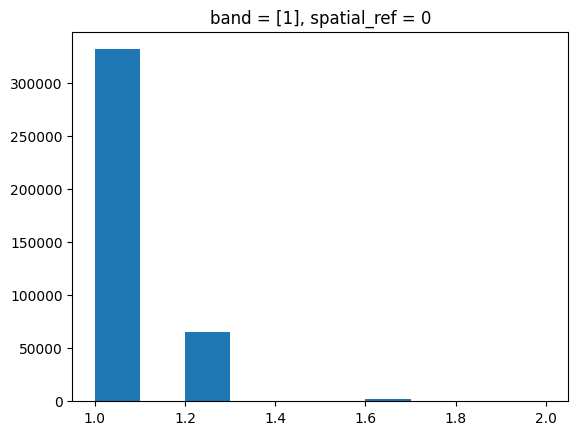

In [140]:
# 1, 1.20000005, 1.60000002, 2
esai_tex.plot.hist()